In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Salary_dataset.csv')

In [3]:
df.head()

,Years_Of_Experience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


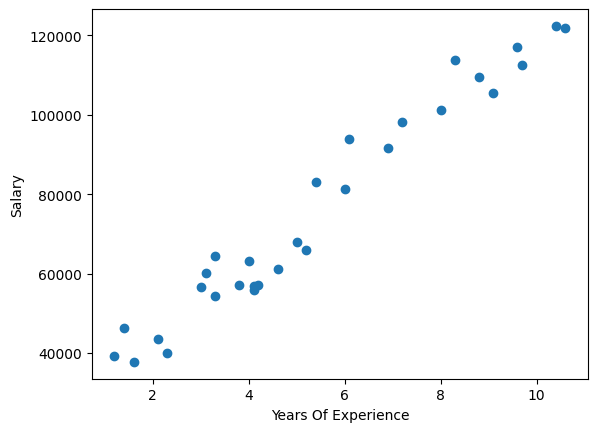

In [4]:
plt.scatter(df['Years_Of_Experience'], df['Salary'])
plt.xlabel('Years Of Experience')
plt.ylabel('Salary')
plt.show()

In [5]:
X = df[['Years_Of_Experience']] # X = df.iloc[:,0].values
y = df[['Salary']] # y = df.iloc[:,1].values


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [ ]:
class LinearRegression:
    def __init__(self):
        self.m = 0.0
        self.b = 0.0

    def fit(self, X_train, y_train, learning_rate=0.01, epochs=10000, tolerance=0.001):
        samples = X_train.shape[0]
        prev_loss = float('inf') # to ensure the loop runs for the 1st iteration, so then the loss gets updated 
        for epoch in range(epochs):
            derivative_m = 0
            derivative_b = 0
            mse = 0
            
            for i in range(samples):
                xi = X_train.iloc[i, 0]
                yi = y_train.iloc[i, 0]
                error = yi - (self.m * xi + self.b)
                mse += error**2
                derivative_b += (-2/samples) * error
                derivative_m += (-2/samples) * xi * error

            current_loss = mse / samples
            if epoch % 100 == 0:
                    print(f"Epoch {epoch}: m = {self.m:.2f}, b = {self.b:.2f}, Loss = {current_loss:.2f}")

            if abs(prev_loss - current_loss) < tolerance:
                break

            prev_loss = current_loss
            self.m = self.m - (learning_rate * (derivative_m))
            self.b = self.b - (learning_rate * (derivative_b))

        from sklearn.linear_model import LinearRegression as SkLearnLR
        self.sklearn_model = SkLearnLR().fit(X_train, y_train)

        print(f"Sklearn values: m = {self.sklearn_model.coef_[0][0]:.2f}, b={self.sklearn_model.intercept_[0]:.2f}")
        print(f"Values from scratch: m = {self.m:.2f}, b = {self.b:.2f}")

    def predict(self, X_test):
        return self.m * X_test + self.b

lr = LinearRegression()

In [8]:
lr.fit(X_train,y_train)

Epoch 0: m = 0.00, b = 0.00, Loss = 6398307634.50
Epoch 100: m = 11330.26, b = 10595.40, Loss = 76228096.07
Epoch 200: m = 10561.54, b = 16015.33, Loss = 45748257.84
Epoch 300: m = 10088.68, b = 19349.25, Loss = 34215445.21
Epoch 400: m = 9797.81, b = 21400.01, Loss = 29851715.78
Epoch 500: m = 9618.90, b = 22661.49, Loss = 28200589.11
Epoch 600: m = 9508.84, b = 23437.45, Loss = 27575843.85
Epoch 700: m = 9441.14, b = 23914.75, Loss = 27339455.78
Epoch 800: m = 9399.50, b = 24208.36, Loss = 27250012.41
Epoch 900: m = 9373.88, b = 24388.96, Loss = 27216169.27
Epoch 1000: m = 9358.13, b = 24500.05, Loss = 27203363.87
Epoch 1100: m = 9348.44, b = 24568.39, Loss = 27198518.62
Epoch 1200: m = 9342.47, b = 24610.42, Loss = 27196685.30
Epoch 1300: m = 9338.81, b = 24636.28, Loss = 27195991.62
Epoch 1400: m = 9336.55, b = 24652.18, Loss = 27195729.14
Epoch 1500: m = 9335.16, b = 24661.97, Loss = 27195629.83
Epoch 1600: m = 9334.31, b = 24667.99, Loss = 27195592.25
Epoch 1700: m = 9333.78, b =

In [9]:
print("Prediction from custom LR: ", lr.predict(X_test.iloc[0,0]))
print("Prediction from Sklearn LR: ", lr.sklearn_model.predict(X_test.iloc[[0]]))

Prediction from custom LR:  75075.35479069325
Prediction from Sklearn LR:  [[75075.50510972]]


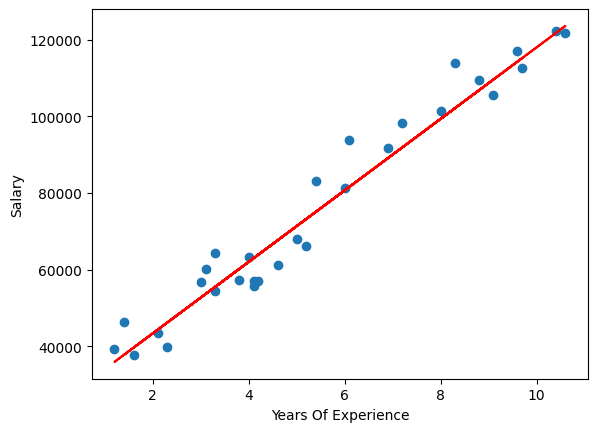

In [10]:
plt.scatter(df['Years_Of_Experience'],df['Salary'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('Years Of Experience')
plt.ylabel('Salary')
plt.show()